# Flow matching and mean flow matching on 2D toy densities

`probjax.nn.generative.flow_matching` learns a velocity field that transports noise to data via an ODE, instead of the exact bijections used by normalizing flows. This trades closed-form likelihoods for a network that is much easier to scale.

This notebook trains `LinearFlow` (standard flow matching, linear interpolation schedule) and `LinearMeanFlow` (mean flow matching, which is trained to predict the *average* velocity between two times so it can sample in very few solver steps) on the same toy datasets used for the normalizing-flow examples.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from flax import nnx

from probjax.nn import LinearFlow, LinearMeanFlow

from data import CheckerboardGenerator, SpiralGenerator
from probjax.nn import TimeMLP

In [2]:
datasets = {
    "checkerboard": CheckerboardGenerator(grid_size=3, scale=4.0),
    "spiral": SpiralGenerator(n_turns=3, radius_scale=4.0, noise_std=0.05),
}

## Flow matching

The network `TimeMLP` (from `probjax.nn`) maps `(t, x) -> velocity`; `LinearFlow` wraps it with a Gaussian-preconditioned linear interpolation between noise and data and takes care of the target-velocity regression loss. Sampling solves the learned ODE from `t=0` to `t=1` with an RK4 solver (`num_steps` controls how many steps that solve takes).

checkerboard: loss 8.435 -> 4.678 (smoothed)
spiral: loss 4.375 -> 3.644 (smoothed)


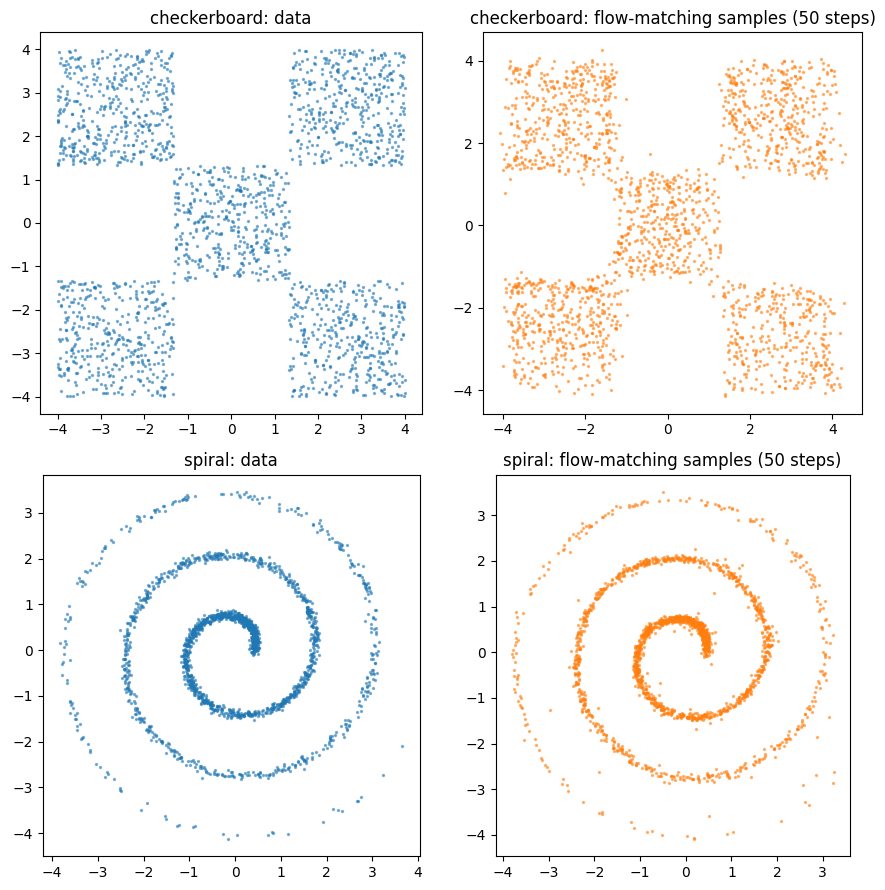

In [5]:
def train_flow_matcher(data, *, num_steps=20_000, seed=0):
    net = TimeMLP(2, rngs=nnx.Rngs(seed))
    model = LinearFlow(net)
    losses = model.fit(jax.random.key(seed + 1), data, num_steps=num_steps, batch_size=256)
    return model, losses


fig, axes = plt.subplots(2, 2, figsize=(9, 9))
flow_matchers = {}
for row, (name, gen) in zip(axes, datasets.items()):
    data = gen.generate(2000, key=jax.random.key(0))
    model, losses = train_flow_matcher(data, seed=hash(name) % 1000)
    flow_matchers[name] = (model, data)
    print(f"{name}: loss {float(losses[:200].mean()):.3f} -> {float(losses[-200:].mean()):.3f} (smoothed)")

    samples = model.as_dist((2,), num_steps=50).sample(jax.random.key(0), (2000,))
    row[0].scatter(data[:, 0], data[:, 1], s=2, alpha=0.5)
    row[0].set_title(f"{name}: data")
    row[1].scatter(samples[:, 0], samples[:, 1], s=2, alpha=0.5, color="C1")
    row[1].set_title(f"{name}: flow-matching samples (50 steps)")
    for ax in row:
        ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## Mean flow matching

`LinearMeanFlow` trains the same kind of network, but on pairs of times `(t, r)` so it directly predicts the *average* velocity between them. That lets sampling take just one or two solver steps instead of tens, at the cost of a slightly harder training objective. Compare the 1-step samples below to the 50-step flow-matching samples above.\n\nNote on `num_steps`: the sampling grid is `linspace(0, 1, num_steps)`, so `num_steps=2` (endpoints `[0, 1]`) is the minimal *one-jump* sampler; `num_steps=1` degenerates to a single grid point and takes zero integration steps.

checkerboard: data std [2.548389 2.485236] vs 7-step sample std [1.9625195 1.8407329]
spiral: data std [1.4235982 1.3912623] vs 7-step sample std [1.3038062 1.1767666]


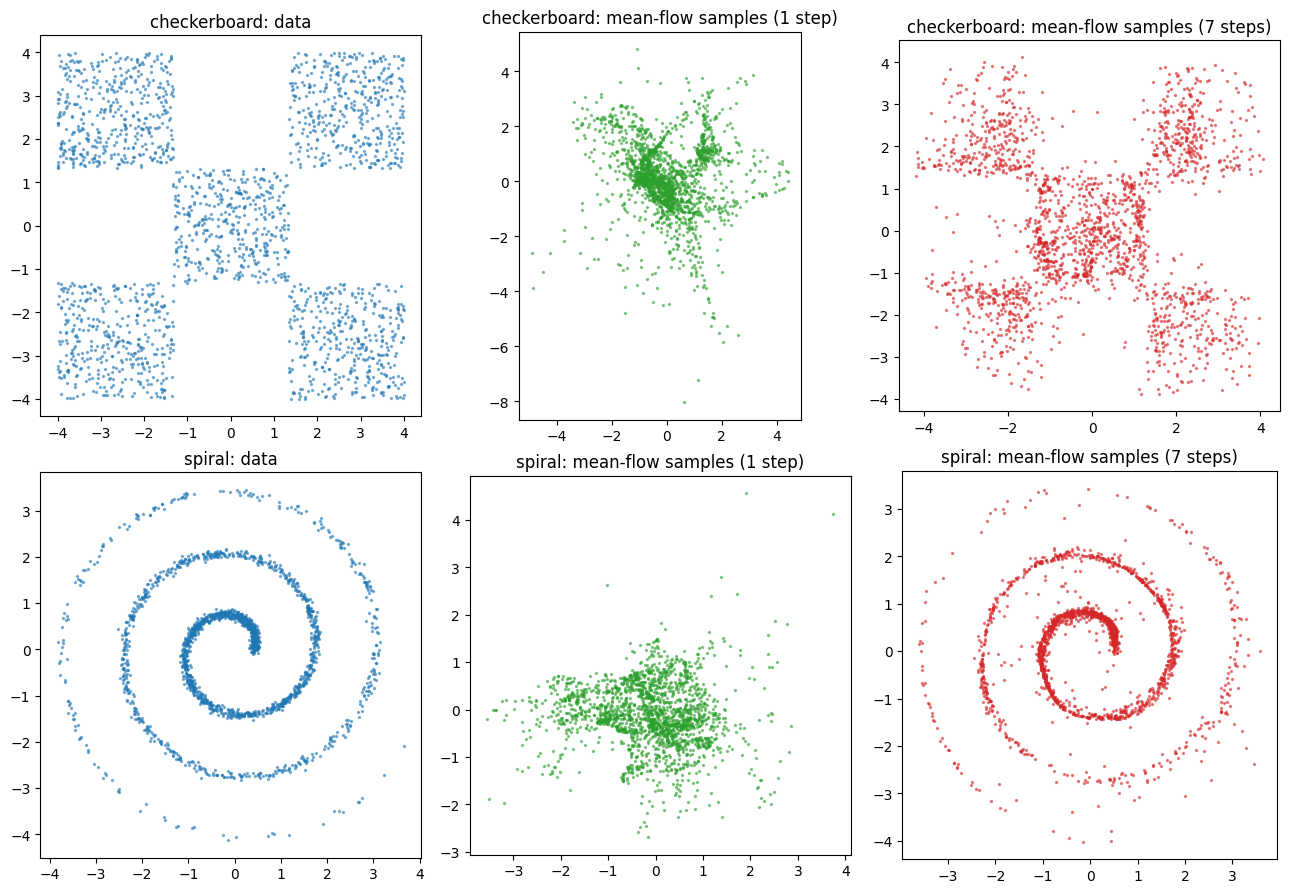

In [7]:
def train_mean_flow(data, *, num_steps=50_000, seed=0):
    net = TimeMLP(2, rngs=nnx.Rngs(seed))
    model = LinearMeanFlow(net)
    losses = model.fit(jax.random.key(seed + 1), data, num_steps=num_steps, batch_size=256)
    return model, losses


fig, axes = plt.subplots(2, 3, figsize=(13, 9))
for row, (name, gen) in zip(axes, datasets.items()):
    data = gen.generate(2000, key=jax.random.key(0))
    model, losses = train_mean_flow(data, seed=hash(name) % 1000)

    samples_1step = model.as_dist((2,), num_steps=2).sample(jax.random.key(0), (2000,))
    samples_4step = model.as_dist((2,), num_steps=8).sample(jax.random.key(0), (2000,))
    # The mean-flow loss curve is noisy (single-minibatch, adaptively
    # weighted); sample statistics are a more direct convergence check.
    print(
        f"{name}: data std {data.std(0)} vs 7-step sample std {samples_4step.std(0)}"
    )

    row[0].scatter(data[:, 0], data[:, 1], s=2, alpha=0.5)
    row[0].set_title(f"{name}: data")
    row[1].scatter(samples_1step[:, 0], samples_1step[:, 1], s=2, alpha=0.5, color="C2")
    row[1].set_title(f"{name}: mean-flow samples (1 step)")
    row[2].scatter(samples_4step[:, 0], samples_4step[:, 1], s=2, alpha=0.5, color="C3")
    row[2].set_title(f"{name}: mean-flow samples (7 steps)")
    for ax in row:
        ax.set_aspect("equal")
plt.tight_layout()
plt.show()